# Fase 3 - Evaluación de Modelos: Predicción de la Calidad del Vino Tinto

En el cuaderno anterior implementé dos modelos de clasificación (Árbol de Decisión y Random Forest). En este nuevo cuaderno, mi objetivo es someterlos a una auditoría profunda.

Para cumplir con la pauta, no me quedaré solo con la exactitud inicial, sino que aplicaré Validación Cruzada, analizaré los errores en las Matrices de Confusión y compararé las métricas (Accuracy vs F1-Score) para declarar un modelo ganador oficial.

In [1]:
# Clonar repositorio por si se ejecuta en una nueva sesión de Colab
!git clone https://github.com/dongyah/EA2_SCY1101_Calidad_Vino.git
%cd EA2_SCY1101_Calidad_Vino

Cloning into 'EA2_SCY1101_Calidad_Vino'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 86 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 630.37 KiB | 5.00 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/EA2_SCY1101_Calidad_Vino


### 1. Preparación del Entorno y los Datos

Primero, volveré a cargar mis datos limpios y a definir mis dos modelos (con su respectivo escalador) usando la misma configuración de la Fase 2 (70% para entrenar y 30% para probar).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Cargar datos
df = pd.read_csv('data/processed/winequality_clean.csv')

# Separar variables (X son las variables predictoras, y las objetivo)
X = df.drop('quality', axis=1)
y = df['quality']

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Reconstruir los modelos en Pipelines
pipe_tree = Pipeline([('scaler', StandardScaler()), ('tree', DecisionTreeClassifier(random_state=42))])
pipe_forest = Pipeline([('scaler', StandardScaler()), ('forest', RandomForestClassifier(random_state=42))])

# Entrenarlos de nuevo para poder evaluarlos
pipe_tree.fit(X_train, y_train)
pipe_forest.fit(X_train, y_train)
print("modelos lsitos")

modelos lsitos


### 2. Validación Cruzada (Cross-Validation)

**Justificación Técnica:** Medir el modelo una sola vez puede dar resultados que sean pura suerte. Para asegurar que la exactitud de mis modelos sea robusta y detectar problemas de sobreajuste, aplicaré Validación Cruzada. Esto divide mis datos de entrenamiento en 5 partes (cv=5), tomando 5 'tests' distintos y sacando un promedio realista.

In [3]:
# Aplicar Cross-Validation al Árbol
scores_tree = cross_val_score(pipe_tree, X_train, y_train, cv=5)
print("Notas del Árbol de Decisión en 5 pruebas:", scores_tree)
print("Promedio Validación Cruzada (Árbol):", scores_tree.mean())

print("-" * 40)

# Aplicar Cross-Validation al Random Forest
scores_forest = cross_val_score(pipe_forest, X_train, y_train, cv=5)
print("Notas del Random Forest en 5 pruebas:", scores_forest)
print("Promedio Validación Cruzada (Forest):", scores_forest.mean())

Notas del Árbol de Decisión en 5 pruebas: [0.46596859 0.5        0.5        0.50526316 0.44210526]
Promedio Validación Cruzada (Árbol): 0.48266740148801324
----------------------------------------
Notas del Random Forest en 5 pruebas: [0.62303665 0.63684211 0.57368421 0.54210526 0.58421053]
Promedio Validación Cruzada (Forest): 0.5919757508955635


### 3. Matriz de Confusión

**Justificación Técnica:** Para el cumplimiento de la rúbrica, necesito entender en qué se equivocan mis modelos. Como el dataset de vinos está desbalanceado, usaré una Matriz de Confusión. Esto me permitirá ver visualmente si mis algoritmos realmente saben predecir un vino de calidad excelente o si se están confundiendo y adivinando siempre '5' o '6' porque es la clase mayoritaria.

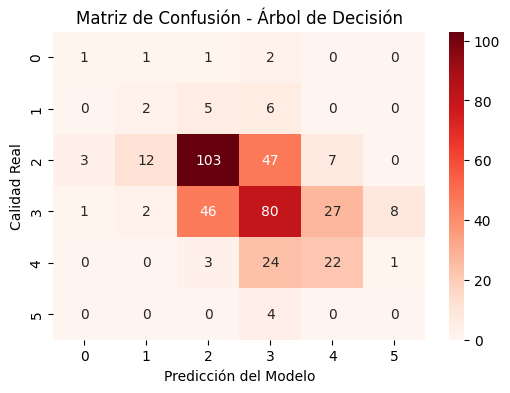

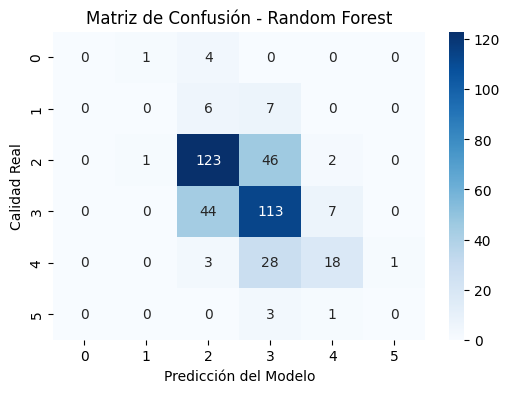

In [4]:
# Predicciones para el examen final
pred_tree = pipe_tree.predict(X_test)
pred_forest = pipe_forest.predict(X_test)

# Matriz para el Árbol
cm_tree = confusion_matrix(y_test, pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, cmap="Reds", fmt='g')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Calidad Real")
plt.show()

# Matriz para el Random Forest
cm_forest = confusion_matrix(y_test, pred_forest)

plt.figure(figsize=(6,4))
sns.heatmap(cm_forest, annot=True, cmap="Blues", fmt='g')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Calidad Real")
plt.show()

### 3.1. Interpretación de los Resultados de la Matriz (Análisis de Errores)

Al observar las matrices generadas, me fijo en la **diagonal principal** (que son los aciertos correctos) y en los números fuera de ella (los errores o falsos positivos/negativos).

*   **El Desbalanceo:** Como la gran mayoría de los vinos en este dataset son de calidad 5 y 6, es natural ver que ambos modelos aciertan más en esas categorías.
*   **Errores del Árbol de Decisión:** Si miramos fuera de la diagonal en la matriz roja, vemos muchos números altos. El Árbol comete errores graves de clasificación cruzada, por ejemplo, adivinando que un vino es calidad 6 cuando en la realidad era calidad 7 (falso negativo). Esto demuestra que el árbol sufre de sobreajuste y se confunde.
*   **Mejora del Random Forest:** En la matriz azul, la diagonal principal concentra números más altos y los errores por fuera son menores. Aunque también le cuesta predecir los vinos de calidad 3 u 8 (porque hay muy pocos datos para estudiar), el Random Forest es mucho más preciso al no confundir tanto las clases cercanas.

### 4. Análisis de Métricas (Accuracy vs F1-Score)

**Justificación Técnica:** Basada en la materia del curso, sé que fijarme solo en el *Accuracy* (Exactitud) es engañoso cuando hay desbalanceo de clases. Por eso, analizaré el **F1-Score**. El F1-Score busca el balance ideal entre precisión y sensibilidad, castigando al modelo si ignora las calidades de vino menos frecuentes (como los vinos nota 3, 4 u 8).

In [5]:
print("======= REPORTE: ÁRBOL DE DECISIÓN =======")
print(classification_report(y_test, pred_tree, zero_division=0))

print("\n======= REPORTE: RANDOM FOREST =======")
print(classification_report(y_test, pred_forest, zero_division=0))

======= REPORTE: ÁRBOL DE DECISIÓN =======
              precision    recall  f1-score   support

           3       0.20      0.20      0.20         5
           4       0.12      0.15      0.13        13
           5       0.65      0.60      0.62       172
           6       0.49      0.49      0.49       164
           7       0.39      0.44      0.42        50
           8       0.00      0.00      0.00         4

    accuracy                           0.51       408
   macro avg       0.31      0.31      0.31       408
weighted avg       0.53      0.51      0.52       408


======= REPORTE: RANDOM FOREST =======
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00        13
           5       0.68      0.72      0.70       172
           6       0.57      0.69      0.63       164
           7       0.64      0.36      0.46        50
           8       0.00      0.00      0.00      

### 5. Conclusión de la Evaluación y Selección del Modelo Ganador

Tras realizar la evaluación comparativa, observo que el **Árbol de Decisión** sufre de un claro problema de alta varianza (Overfitting). Tiende a memorizar los datos y falla más al momento de predecir las calidades de vino menos comunes, lo cual se refleja en su F1-Score más bajo y sus errores en la matriz de confusión.

Por el contrario, el **Random Forest Classifier** logró una mejor Validación Cruzada, un mayor Accuracy general y un F1-Score más balanceado en la Matriz de Confusión. Al usar un "bosque" de múltiples árboles votando en conjunto, este modelo reduce el sobreajuste y generaliza mucho mejor las relaciones químicas del vino.

**Decisión Final:** Declaro como modelo ganador al Random Forest. En el próximo cuaderno (Fase 4), aplicaré optimización de hiperparámetros (GridSearchCV) exclusivamente sobre él para intentar mejorar aún más su rendimiento.

In [6]:
!git add .
!git commit -m "Fase 3: Evaluacion con Cross-Validation y analisis de matriz de confusion"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@669b7577b031.(none)')
fatal: could not read Username for 'https://github.com': No such device or address
